<a href="https://colab.research.google.com/github/unidari/ml/blob/main/ml_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №7. Random forest**

## **Задание 1. Обучите классификатор Random Forest для решения задачи бинарной классификации: для каждого человека научиться предсказывать, выживет ли он при крушении Титаника.**



Ссылка на датасет: https://www.kaggle.com/c/titanic/data

### 1. Устанавливаем зависимости

In [29]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Импортируем датасет

In [30]:
!wget 'https://drive.google.com/uc?export=download&id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB' -O test.csv
!wget 'https://drive.google.com/uc?export=download&id=1oDzBtqrXFDnc4ABbAi5hy9UXXT5uVdbD' -O train.csv

--2026-05-25 18:27:32--  https://drive.google.com/uc?export=download&id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB
Resolving drive.google.com (drive.google.com)... 173.194.194.101, 173.194.194.139, 173.194.194.138, ...
Connecting to drive.google.com (drive.google.com)|173.194.194.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB&export=download [following]
--2026-05-25 18:27:32--  https://drive.usercontent.google.com/download?id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.189.132, 2607:f8b0:4001:c6c::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.189.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28629 (28K) [application/octet-stream]
Saving to: ‘test.csv’

test.csv            100%[===================>]  27.96K  --.-KB/s   

In [31]:
df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3. Производим разведовательный анализ данных


Получим представление о данных в датасете:

In [32]:
df.info()
display(df.describe())
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


(891, 12)

In [33]:
test_df.info()
display(test_df.describe())
test_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


(418, 11)

### 4. Сформируем обучающую и тестовую выборки:


In [34]:
from sklearn.model_selection import train_test_split

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

df = df.drop('Cabin', axis=1)
df['Age'] = df['Age'].fillna(df['Age'].mean())

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(X_train.shape, X_test.shape)

(623, 11) (268, 11)


### 5. Feature Engineering

Поработаем с признаками, выделим важные, изменим форму их представления (при надобности)

In [35]:
X_train2 = X_train.drop(columns=["Name", "Ticket", "PassengerId"])
X_test2 = X_test.drop(columns=["Name", "Ticket", "PassengerId"])

print(X_train2.shape)

X_train2.info()
X_train2.head(10)

(623, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 623 entries, 445 to 102
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      623 non-null    int64  
 1   Age         623 non-null    float64
 2   SibSp       623 non-null    int64  
 3   Parch       623 non-null    int64  
 4   Fare        623 non-null    float64
 5   Sex_male    623 non-null    bool   
 6   Embarked_Q  623 non-null    bool   
 7   Embarked_S  623 non-null    bool   
dtypes: bool(3), float64(2), int64(3)
memory usage: 31.0 KB


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
445,1,4.000000,0,2,81.8583,True,False,True
650,3,29.699118,0,0,7.8958,True,False,True
172,3,1.000000,1,1,11.1333,False,False,True
450,2,36.000000,1,2,27.7500,True,False,True
314,2,43.000000,1,1,26.2500,True,False,True
332,1,38.000000,0,1,153.4625,True,False,True
801,2,31.000000,1,1,26.2500,False,False,True
90,3,29.000000,0,0,8.0500,True,False,True
834,3,18.000000,0,0,8.3000,True,False,True
181,2,29.699118,0,0,15.0500,True,False,False


### 6. Построение базовой модели:

In [36]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_test2)

### 7. Оценка точности модели:

#### 7.1. Напишите функцию, принимающую на вход аргументы y_pred, y_test и выполняющую визуализацию матрицы ошибок и отчета классификации

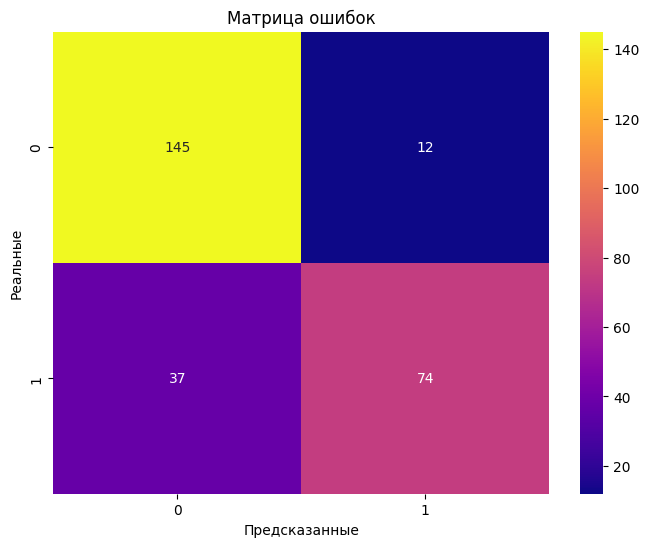

In [37]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

def function(y_pred, y_test):
  cm = confusion_matrix(y_test, y_pred)

  plt.figure(figsize=(8, 6))
  sns.heatmap(cm,
              annot=True,
              fmt=".0f",
              cmap='plasma')

  plt.title('Матрица ошибок')
  plt.xlabel('Предсказанные')
  plt.ylabel('Реальные')
  plt.show()


function(y_pred, y_test)

#### 7.2. Оцените точность модели:

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86       157
           1       0.86      0.67      0.75       111

    accuracy                           0.82       268
   macro avg       0.83      0.80      0.80       268
weighted avg       0.82      0.82      0.81       268



### 8. Тюнинг гиперпараметров модели:

#### RandomSearchCV

In [39]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_grid = {
    'n_estimators': np.linspace(10, 300, 5, dtype=int),
    'max_leaf_nodes': np.linspace(2, 50, 5, dtype=int),
    'max_depth': [*np.linspace(1, 80, 5, dtype=int), None]
}

rf_rcv = RandomizedSearchCV(
    model, param_grid,
    n_iter=50,
    scoring='accuracy',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_rcv.fit(X_train2, y_train)

best_params = {k: (int(v) if v is not None else None) for k, v in rf_rcv.best_params_.items()}
print(f"Лучшие параметры: {best_params}")
print(f"Лучшая точность: {rf_rcv.best_score_:.3f}")

Лучшие параметры: {'n_estimators': 300, 'max_leaf_nodes': 14, 'max_depth': 80}
Лучшая точность: 0.827


#### GridSearchCV

In [40]:
from sklearn.model_selection import GridSearchCV
import numpy as np

param_grid = {
    'n_estimators': np.linspace(10, 300, 5, dtype=int),
    'max_leaf_nodes': np.linspace(2, 50, 5, dtype=int),
    'max_depth': [*np.linspace(1, 80, 5, dtype=int), None]
}

rf_gs = GridSearchCV(
    model, param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=0
)
rf_gs.fit(X_train2, y_train)

best_params = {k: (int(v) if v is not None else None) for k, v in rf_gs.best_params_.items()}
print(f"Лучшие параметры: {best_params}")
print(f"Лучшая точность: {rf_gs.best_score_:.3f}")

Лучшие параметры: {'max_depth': 20, 'max_leaf_nodes': 14, 'n_estimators': 300}
Лучшая точность: 0.827


### 9. Комплексная оценка точности лучшей модели:

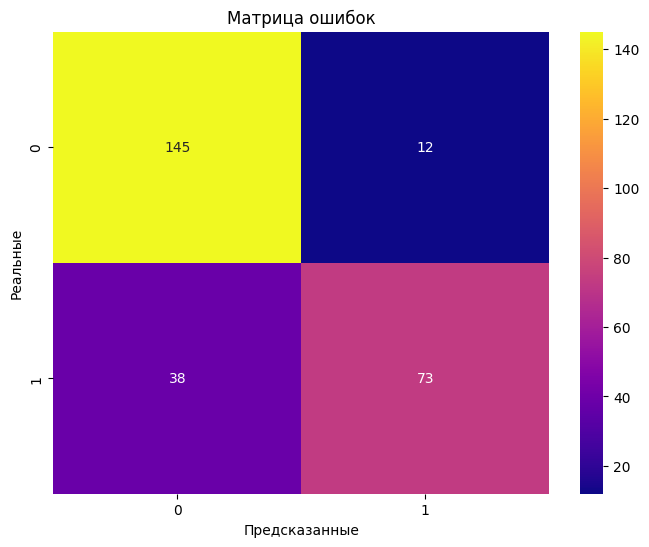

In [41]:
best_model = RandomForestClassifier(n_estimators=300, max_leaf_nodes=14, max_depth=20, random_state=42)
best_model.fit(X_train2, y_train)
y_pred = best_model.predict(X_test2)
function(y_pred, y_test)

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.92      0.85       157
           1       0.86      0.66      0.74       111

    accuracy                           0.81       268
   macro avg       0.83      0.79      0.80       268
weighted avg       0.82      0.81      0.81       268



## **Задание 2. Решите задачу из предыдущего пункта используя другие, ранее пройденные классификаторы. Сравните их точность предсказания с Random Forest**

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

models = {
    'LogisticRegression': make_pipeline(StandardScaler(), LogisticRegression(random_state=42, max_iter=1000)),
    'KNeighborsClassifier': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
}

for name, model in models.items():
    model.fit(X_train2, y_train)
    y_pred = model.predict(X_test2)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}\nТочность модели: {acc:.4f}")

print('RandomForest точность: 0.827')

LogisticRegression
Точность модели: 0.8097
KNeighborsClassifier
Точность модели: 0.7910
RandomForest точность: 0.827


## **Задание 2.1. Реализуйте функцию, для взаимодействия с обученной Вами моделью**



* Функция должна принимать на вход обученную модель классификатора;

* После вызова функции, у пользователя через консоль запрашиваются значения признаков. При запросе значений нужно вывести пояснения о типе и диапазоне возможных значений. Также реализуйте обработку исключений;

* После ввода значений для всех признаков в консоль, выводится результат работы классификатора.

In [44]:
import pandas as pd

def prediction(model):
    print("Введите данные пассажира для предсказания:\n")
    data = {}
    #Pclass
    while True:
        try:
            pclass = int(input("Класс пассажира (1, 2 или 3): "))
            if pclass in [1, 2, 3]:
                data['Pclass'] = pclass
                break
            else:
                print("Ошибка: введите 1, 2 или 3.")
        except ValueError:
            print("Ошибка: нужно ввести целое число.")

    #Возраст
    while True:
        try:
            data['Age'] = int(input("Возраст (полных лет): "))
            break
        except ValueError:
            print("Ошибка: введите целое число.")

    #SibSp
    while True:
        try:
            data['SibSp'] = int(input("Количество супругов/братьев/сестёр на борту: "))
            break
        except ValueError:
            print("Ошибка: введите целое число.")

    #Parch
    while True:
        try:
            data['Parch'] = int(input("Количество родителей/детей на борту: "))
            break
        except ValueError:
            print("Ошибка: введите целое число.")

    #Fare
    while True:
        try:
            data['Fare'] = int(input("Стоимость билета (в долларах, целое число): "))
            break
        except ValueError:
            print("Ошибка: введите целое число.")

    #Пол
    while True:
        sex = input("Пол (male/female): ").lower()
        if sex == 'male':
            data['Sex_male'] = 1
            break
        elif sex == 'female':
            data['Sex_male'] = 0
            break
        else:
            print("Ошибка: введите 'male' или 'female'.")

    #Город отправки
    while True:
        emb = input("Порт отправки (S = Саутгемптон, C = Шербур, Q = Квинстаун): ").upper()
        if emb == 'S':
            data['Embarked_Q'] = 0
            data['Embarked_S'] = 1
            break
        elif emb == 'C':
            data['Embarked_Q'] = 0
            data['Embarked_S'] = 0
            break
        elif emb == 'Q':
            data['Embarked_Q'] = 1
            data['Embarked_S'] = 0
            break
        else:
            print("Ошибка: введите S, C или Q.")

    input_df = pd.DataFrame([data])
    prediction = model.predict(input_df)[0]

    if prediction == 1:
        print("Пассажир выживет!")
    else:
        print("Пассажир не выживет")

prediction(model)

Введите данные пассажира для предсказания:

Класс пассажира (1, 2 или 3): 3
Возраст (полных лет): 20
Количество супругов/братьев/сестёр на борту: 1
Количество родителей/детей на борту: 1
Стоимость билета (в долларах, целое число): 25
Пол (male/female): male
Порт отправки (S = Саутгемптон, C = Шербур, Q = Квинстаун): S
Пассажир не выживет


## **Задание 3. Решите задачу регрессии, используя [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html).**

**ОБЯЗАТЕЛЬНО ОСУЩЕСТВИТЕ ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ, ИСПОЛЬЗУЯ RandomSearchCV и GridSearchCV**



* Для выполнения данного задания можете использовать **любой датасет**



Ссылка на один из сайтов-источников датасетов: https://www.kaggle.com/datasets?tags=14203-Regression

In [49]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

housing = load_diabetes()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [int(x) for x in np.linspace(50, 500, 10)],
    'max_depth': [None] + [int(x) for x in np.linspace(5, 50, 10)],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

print("Лучшие параметры (Random Search):", random_search.best_params_)
print("Лучший RMSE (Random Search):", np.sqrt(-random_search.best_score_))

best_params = random_search.best_params_

param_grid = {
    'n_estimators': [best_params['n_estimators'] - 50, best_params['n_estimators'], best_params['n_estimators'] + 50],
    'max_depth': [best_params['max_depth'] - 5, best_params['max_depth'], best_params['max_depth'] + 5],
    'min_samples_split': [best_params['min_samples_split']],
    'min_samples_leaf': [best_params['min_samples_leaf']],
    'max_features': [best_params['max_features']]
}

param_grid = {k: list(set(v)) for k, v in param_grid.items()}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Лучшие параметры (Grid Search):", grid_search.best_params_)
print("Лучший RMSE (Grid Search):", np.sqrt(-grid_search.best_score_))

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Качество модели на тестовых данных:")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

feature_importance = best_model.feature_importances_
importance_df = pd.DataFrame({'feature': housing.feature_names, 'importance': feature_importance})
importance_df = importance_df.sort_values('importance', ascending=False)
print("Важность признаков:")
print(importance_df)

Лучшие параметры (Random Search): {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 35}
Лучший RMSE (Random Search): 57.50646387029437
Лучшие параметры (Grid Search): {'max_depth': 40, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}
Лучший RMSE (Grid Search): 57.50646387029437
Качество модели на тестовых данных:
RMSE: 53.4382
R2: 0.4610
Важность признаков:
  feature  importance
2     bmi    0.254086
8      s5    0.207052
3      bp    0.119120
6      s3    0.082568
9      s6    0.079483
5      s2    0.065887
7      s4    0.063908
4      s1    0.058938
0     age    0.057004
1     sex    0.011953


## **Задание №4. Интерпретация моделей, основанных на решающих деревьях, в задачах контроля качества**

- Для компании-произвозителя собачьего корма, необходимо попытаться предсказать, почему некоторые партии их корма портятся гораздо быстрее, чем предполагалось.

- К сожалению, эта компания по производству собачьего корма не обновила свое оборудование до последних моделей, что означает, что количество пяти консервантов, которые они используют, может значительно варьироваться. Но какой из консервантов оказывает наибольшее влияние?

- Сначала компания по производству собачьего корма готовит партию консерванта, которая содержит 4 разных консерванта (A, B, C, D), а затем добавляет "наполнитель". Ученые полагают, что один из консервантов A, B, C или D вызывает проблему и необходимо выяснить, какой именно.



Используйте алгоритм случайного леса (Random Forest) для определения важности признаков. На основе полученных результатов установите, какой именно консервант (A, B, C или D) в наибольшей степени влияет на преждевременную порчу партий собачьего корма.

* Pres_A : Процент консерванта A в смеси
* Pres_B : Процент консерванта B в смеси
* Pres_C : Процент консерванта C в смеси
* Pres_D : Процент консерванта D в смеси
* Spoiled: Метка, указывающая, испортилась ли партия собачьего корма.



#### **Загрузка исходные данных (запустите эту ячейку!)**

In [50]:
%%capture
!git clone --recursive https://github.com/tester170/Other.git
!ls Other/
!unzip "/content/Other/data.zip" -d "/content/"

___

#### **Тщательно подумайте о том, что на самом деле требуется решить в этой задаче!**
____

In [51]:
import pandas as pd

data = pd.read_csv('data/dog_food.csv')

In [52]:
data.head()

,A,B,C,D,Spoiled
0,4,2,12.0,3,1.0
1,5,6,12.0,7,1.0
2,6,2,13.0,6,1.0
3,4,2,12.0,1,1.0
4,4,2,12.0,3,1.0


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.drop('Spoiled', axis=1), data['Spoiled'], test_size = 0.33, random_state = 42)
X_train.shape, X_test.shape

((328, 4), (162, 4))

In [54]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [57]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

max_depth = [int(i) for i in np.linspace(start=1, stop=50, num=10)]
max_depth.append(None)

param_grid = {'n_estimators': [int(x) for x in np.linspace(start=200, stop=300, num=5)],
              'max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=100, num=5)],
              'max_depth': max_depth}

rf_rcv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=100,
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_rcv.fit(X_train, y_train)
best_model = rf_rcv.best_estimator_
print(best_model)

RandomForestClassifier(max_depth=6, max_leaf_nodes=26, n_estimators=200,
                       random_state=42)


In [61]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(max_depth=6, max_leaf_nodes=26, n_estimators=200, random_state=42)
best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)
f = X_test.copy()
f['Spoiled'] = pred
f = f[f['Spoiled'] != 0] #тут только испорченные партии
#больше значение, тем больше влияние консерванта на партию
for i in f.columns:
  if i != 'Spoiled': print(f'{i}: {f[i].sum()}')

A: 294
B: 269
C: 615.0
D: 294
